
# Evaluation — Multi-run Leaderboard & BM25 Variant Plots (no bootstrap)

This notebook supports three modes:

1. **GLOBAL** — Compare across all methods but **only** the canonical BM25 runs (`bm25_unigram`, `bm25_unibigram`).
2. **LEXICAL** - Compare across all **lexical** methods but only canonical BM25 runs
3. **BM25_VARIANTS** — Focused evaluation of **all variants** for a chosen BM25 family (e.g., every `bm25_unigram_*` run).
4. **DENSE* - Compare across all **dense** methods (file name: "dense_*")

Artifacts expected from previous steps:
- Each run folder under `/work/runs/<method>/` contains `metrics_dual.json` written by the per-method evaluator.  
- This structure is produced by your retrieval → metrics workflow.



## Config
- `EVAL_MODE`: `"GLOBAL"` or `"LEXICAL"` or `DENSE` or `"BM25_VARIANTS"`  
- If `BM25_VARIANTS`, set `BM25_FAMILY` to `"bm25_unigram"` or `"bm25_unibigram"`.


In [1]:
from pathlib import Path
import json, os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paths ---
RUNS_ROOT = Path("/work/runs")
EVAL_OUT  = Path("/work/eval") # eval, eval/bm25_unigram,  eval/bm25_unibigram
EVAL_OUT.mkdir(parents=True, exist_ok=True)

# --- Mode ---
EVAL_MODE    = "GLOBAL"          # "GLOBAL" | "BM25_VARIANTS" / "LEXICAL" / "DENSE"
BM25_FAMILY  = "bm25_unigram_params"    # only used when EVAL_MODE == "BM25_VARIANTS"
ALLOWED_BM25 = {"bm25_unigram", "bm25_unibigram", "bm25_unigram_params"}  # only these among BM25 in GLOBAL mode

print("RUNS_ROOT:", RUNS_ROOT)
print("EVAL_OUT :", EVAL_OUT)
print("EVAL_MODE:", EVAL_MODE, "| BM25_FAMILY:", BM25_FAMILY)
print("ALLOWED_BM25:", ALLOWED_BM25)


RUNS_ROOT: /work/runs
EVAL_OUT : /work/eval
EVAL_MODE: GLOBAL | BM25_FAMILY: bm25_unigram_params
ALLOWED_BM25: {'bm25_unigram_params', 'bm25_unigram', 'bm25_unibigram'}



## Discovery helpers
We scan `/work/runs/<method>/metrics_dual.json`.

- **GLOBAL**: include everything except BM25 sweeps; only `bm25_unigram` & `bm25_unibigram`.
- **LEXICAL** lexical indexes execpt BM25 sweeps
- **DENSE** dense indexes
- **BM25_VARIANTS**: include **all** methods whose folder starts with `BM25_FAMILY`.


In [2]:
def _metrics_dual_path(run_dir: Path) -> Path:
    return run_dir / "metrics_dual.json"

def _is_excluded(method_name: str) -> bool:
    """Exclude any methods we don't want globally (like prf*)"""
    return method_name.lower().startswith("prf")

def _is_selected_bm25(method_name: str, allowed_set) -> bool:
    return method_name.lower() in {m.lower() for m in allowed_set}

def _is_dense(method_name: str) -> bool:
    """Dense methods are named 'dense_*'"""
    return method_name.lower().startswith("dense")

def _should_include_global(method_name: str, allowed_bm25) -> bool:
    name = method_name.lower()
    if name.startswith("bm25"):
        return _is_selected_bm25(name, allowed_bm25)
    return True  # include non-BM25 by default

def _should_include_bm25_variants(method_name: str, family: str) -> bool:
    return method_name.lower().startswith(family.lower())

def discover_runs(runs_root: Path, mode: str, allowed_bm25, family: str) -> dict:
    runs = {}
    if not runs_root.exists():
        return runs
    for sub in runs_root.iterdir():
        if not sub.is_dir():
            continue
        method = sub.name  # /work/runs/<method>
        md = _metrics_dual_path(sub)
        if not md.exists():
            continue

        # --- Exclude unwanted methods ---
        if _is_excluded(method):
            continue
            
        if mode == "GLOBAL":
            if _should_include_global(method, allowed_bm25):
                runs[method] = sub
        elif mode =="BM25_VARIANTS":
            if _should_include_bm25_variants(method, family):
                runs[method] = sub
        elif mode == "LEXICAL":
            if _should_include_global(method, allowed_bm25) and not _is_dense(method):
                runs[method] = sub
        elif mode == "DENSE":
            if _is_dense(method):
                runs[method] = sub
    return dict(sorted(runs.items()))

runs = discover_runs(RUNS_ROOT, EVAL_MODE, ALLOWED_BM25, BM25_FAMILY)
print(f"Selected runs ({len(runs)}):")
for k,v in runs.items():
    print(" -", k, "->", v)


Selected runs (13):
 - bm25_unibigram -> /work/runs/bm25_unibigram
 - bm25_unigram -> /work/runs/bm25_unigram
 - bm25_unigram_params -> /work/runs/bm25_unigram_params
 - dense_e5 -> /work/runs/dense_e5
 - dense_es_hiiamsid -> /work/runs/dense_es_hiiamsid
 - dense_gte -> /work/runs/dense_gte
 - dense_gte_instrQ -> /work/runs/dense_gte_instrQ
 - rrf__bm25_char_e5 -> /work/runs/rrf__bm25_char_e5
 - tfidf_char_3_5 -> /work/runs/tfidf_char_3_5
 - tfidf_unigram -> /work/runs/tfidf_unigram
 - tfidf_unigram_nostop -> /work/runs/tfidf_unigram_nostop
 - tfidf_unigram_phrases_add -> /work/runs/tfidf_unigram_phrases_add
 - tfidf_unigram_phrases_replace -> /work/runs/tfidf_unigram_phrases_replace



## Load metrics
Use the `metrics_dual.json` file saved by the per-method evaluation to build a unified dataframe.


In [3]:

def load_metrics_dual(method: str, run_dir: Path) -> pd.DataFrame:
    p = run_dir / "metrics_dual.json"
    with open(p, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    # Ensure standard columns
    std_cols = ["method","target","scope","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"]
    if "method" not in df.columns:
        df["method"] = method
    for col in std_cols:
        if col not in df.columns:
            df[col] = None
    df = df[std_cols]
    # Sort for display
    order = {"overall":0, "has_numbers":1, "no_numbers":2}
    df["__scope_order__"] = df["scope"].map(order).fillna(99)
    df = df.sort_values(["target","__scope_order__","method"]).drop(columns="__scope_order__")
    return df

frames = []
for m, p in runs.items():
    try:
        frames.append(load_metrics_dual(m, p))
    except Exception as e:
        print(f"[WARN] Failed to load {m}: {e}")

if frames:
    df_metrics = pd.concat(frames, ignore_index=True)
else:
    df_metrics = pd.DataFrame(columns=["method","target","scope","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"])

print("Loaded rows:", len(df_metrics))
display(df_metrics.head(10))

# Save the raw merged table
suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
df_metrics.to_csv(EVAL_OUT / f"all_metrics_dual_merged__{suffix}.csv", index=False)
df_metrics.to_json(EVAL_OUT / f"all_metrics_dual_merged__{suffix}.json", orient="records", indent=2, force_ascii=False)
print("Saved merged metrics to", EVAL_OUT)


Loaded rows: 78


,method,target,scope,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,bm25_unibigram__k1-0.80__b-0.35,item,overall,16590.0,0.826703,0.868596,0.869681,0.844137,0.849523
1,bm25_unibigram__k1-0.80__b-0.35,item,has_numbers,16561.0,0.826460,0.868426,0.869513,0.843924,0.849320
2,bm25_unibigram__k1-0.80__b-0.35,item,no_numbers,29.0,0.965517,0.965517,0.965517,0.965990,0.965517
3,bm25_unibigram__k1-0.80__b-0.35,parent,overall,16590.0,0.872634,0.881374,0.881555,0.876773,0.847621
4,bm25_unibigram__k1-0.80__b-0.35,parent,has_numbers,16561.0,0.872471,0.881227,0.881408,0.876617,0.847415
5,bm25_unibigram__k1-0.80__b-0.35,parent,no_numbers,29.0,0.965517,0.965517,0.965517,0.965990,0.965517
6,bm25_unigram__k1-0.80__b-0.35,item,overall,16590.0,0.869078,0.932248,0.950271,0.897783,0.908898
7,bm25_unigram__k1-0.80__b-0.35,item,has_numbers,16561.0,0.868969,0.932130,0.950184,0.897680,0.908796
8,bm25_unigram__k1-0.80__b-0.35,item,no_numbers,29.0,0.931034,1.000000,1.000000,0.956897,0.967642
9,bm25_unigram__k1-0.80__b-0.35,parent,overall,16590.0,0.972875,0.975407,0.979747,0.975224,0.942242


Saved merged metrics to /work/eval



## Leaderboard tables (Overall)
Paper-ready tables summarizing item- and parent-level metrics for the **Overall** scope.


In [4]:

def leaderboard(df: pd.DataFrame, target: str) -> pd.DataFrame:
    d = (df[(df["target"]==target) & (df["scope"].str.lower()=="overall")]
          .copy())
    cols = ["method","queries","Acc@1","Recall@5","Recall@10","MRR","nDCG@10"]
    d = d[cols].sort_values(["Acc@1","MRR","nDCG@10"], ascending=False).reset_index(drop=True)
    return d

lb_item   = leaderboard(df_metrics, target="item")
lb_parent = leaderboard(df_metrics, target="parent")

print("Item-level leaderboard (Overall)")
display(lb_item.style.format({"Acc@1":"{:.3f}","Recall@5":"{:.3f}","Recall@10":"{:.3f}","MRR":"{:.3f}","nDCG@10":"{:.3f}"}))
print("Parent-level leaderboard (Overall)")
display(lb_parent.style.format({"Acc@1":"{:.3f}","Recall@5":"{:.3f}","Recall@10":"{:.3f}","MRR":"{:.3f}","nDCG@10":"{:.3f}"}))

# Save
suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
lb_item.to_csv(EVAL_OUT / f"leaderboard_item_overall__{suffix}.csv", index=False)
lb_parent.to_csv(EVAL_OUT / f"leaderboard_parent_overall__{suffix}.csv", index=False)


Item-level leaderboard (Overall)


,method,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,bm25_unigram_params__k1-0.60__b-0.35,16590.000000,0.974,0.985,0.985,0.979,0.980
1,bm25_unigram__k1-0.80__b-0.35,16590.000000,0.869,0.932,0.950,0.898,0.909
2,bm25_unibigram__k1-0.80__b-0.35,16590.000000,0.827,0.869,0.870,0.844,0.850
3,tfidf_unigram_phrases_replace,16590.000000,0.708,0.834,0.850,0.761,0.781
4,tfidf_unigram_phrases_add,16590.000000,0.650,0.847,0.919,0.735,0.776
5,tfidf_unigram_nostop,16590.000000,0.642,0.758,0.829,0.692,0.721
6,tfidf_unigram,16590.000000,0.627,0.753,0.808,0.685,0.708
7,tfidf_char_3_5,16590.000000,0.558,0.628,0.648,0.588,0.599
8,rrf__bm25_char_e5,16590.000000,0.496,0.799,0.854,0.627,0.679
9,dense_e5,16589.000000,0.134,0.376,0.518,0.251,0.303


Parent-level leaderboard (Overall)


,method,queries,Acc@1,Recall@5,Recall@10,MRR,nDCG@10
0,tfidf_unigram_phrases_replace,16590.000000,0.990,0.990,0.990,0.990,0.973
1,rrf__bm25_char_e5,16590.000000,0.987,0.994,0.997,0.990,0.950
2,tfidf_unigram_nostop,16590.000000,0.986,0.988,0.988,0.987,0.976
3,bm25_unigram_params__k1-0.60__b-0.35,16590.000000,0.985,0.994,0.994,0.990,0.744
4,dense_e5,16589.000000,0.982,0.993,0.996,0.987,0.969
5,bm25_unigram__k1-0.80__b-0.35,16590.000000,0.973,0.975,0.980,0.975,0.942
6,tfidf_unigram,16590.000000,0.947,0.973,0.983,0.956,0.944
7,tfidf_unigram_phrases_add,16590.000000,0.940,0.984,0.989,0.956,0.829
8,bm25_unibigram__k1-0.80__b-0.35,16590.000000,0.873,0.881,0.882,0.877,0.848
9,dense_gte,16589.000000,0.837,0.941,0.961,0.884,0.701



## Numeric vs non-numeric splits (Item-level)
We pivot the **item-level** metrics to compare *Has numbers* vs *No numbers* across methods.


In [5]:

def numeric_split_table(df: pd.DataFrame, metric: str = "Acc@1") -> pd.DataFrame:
    d = df[(df["target"]=="item") & (df["scope"].isin(["has_numbers","no_numbers"]))].copy()
    d["scope"] = d["scope"].replace({"has_numbers":"Has numbers", "no_numbers":"No numbers"})
    pivot = d.pivot_table(index="method", columns="scope", values=metric, aggfunc="first")
    # Align to leaderboard order if not empty
    order = lb_item["method"] if not lb_item.empty else pivot.index
    pivot = pivot.reindex(order)
    return pivot

tbl_acc1 = numeric_split_table(df_metrics, "Acc@1")
tbl_recall10 = numeric_split_table(df_metrics, "Recall@10")
display(tbl_acc1.style.format("{:.3f}").set_caption("Item-level Acc@1 — Numeric vs No-numeric"))
display(tbl_recall10.style.format("{:.3f}").set_caption("Item-level Recall@10 — Numeric vs No-numeric"))

suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
tbl_acc1.to_csv(EVAL_OUT / f"numeric_split_item_acc1__{suffix}.csv")
tbl_recall10.to_csv(EVAL_OUT / f"numeric_split_item_recall10__{suffix}.csv")


scope,Has numbers,No numbers
method,,
bm25_unigram_params__k1-0.60__b-0.35,0.974,1.000
bm25_unigram__k1-0.80__b-0.35,0.869,0.931
bm25_unibigram__k1-0.80__b-0.35,0.826,0.966
tfidf_unigram_phrases_replace,0.708,1.000
tfidf_unigram_phrases_add,0.649,1.000
tfidf_unigram_nostop,0.641,1.000
tfidf_unigram,0.626,1.000
tfidf_char_3_5,0.558,1.000
rrf__bm25_char_e5,0.496,0.966


scope,Has numbers,No numbers
method,,
bm25_unigram_params__k1-0.60__b-0.35,0.985,1.000
bm25_unigram__k1-0.80__b-0.35,0.950,1.000
bm25_unibigram__k1-0.80__b-0.35,0.870,0.966
tfidf_unigram_phrases_replace,0.850,1.000
tfidf_unigram_phrases_add,0.919,1.000
tfidf_unigram_nostop,0.829,1.000
tfidf_unigram,0.807,1.000
tfidf_char_3_5,0.647,1.000
rrf__bm25_char_e5,0.854,1.000



## Plots (paper-ready)
Matplotlib only, one figure per plot, no explicit colors or styles.


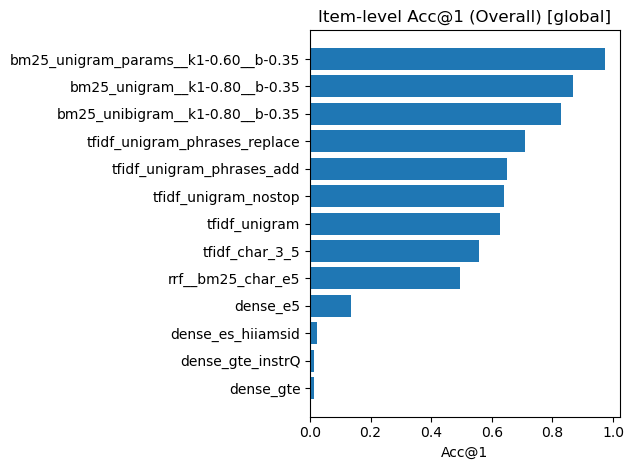

Saved plot: /work/eval/plot_item_acc1__global.png


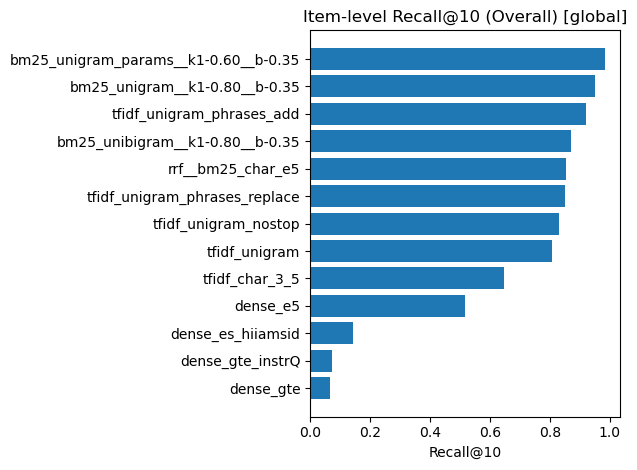

Saved plot: /work/eval/plot_item_recall10__global.png


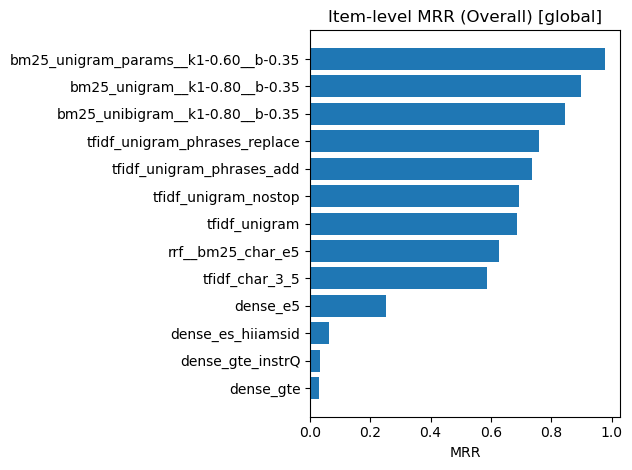

Saved plot: /work/eval/plot_item_mrr__global.png


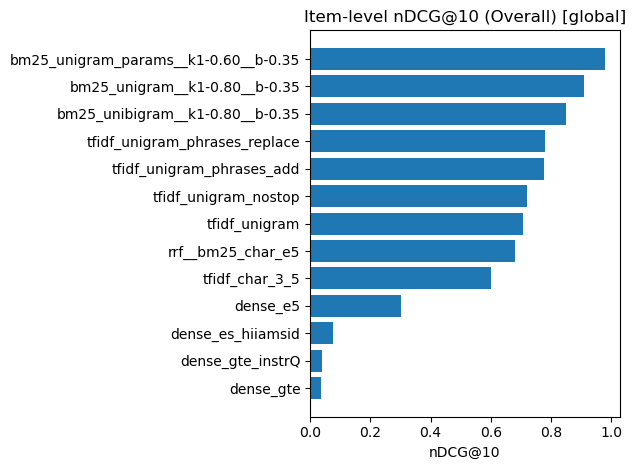

Saved plot: /work/eval/plot_item_ndcg10__global.png


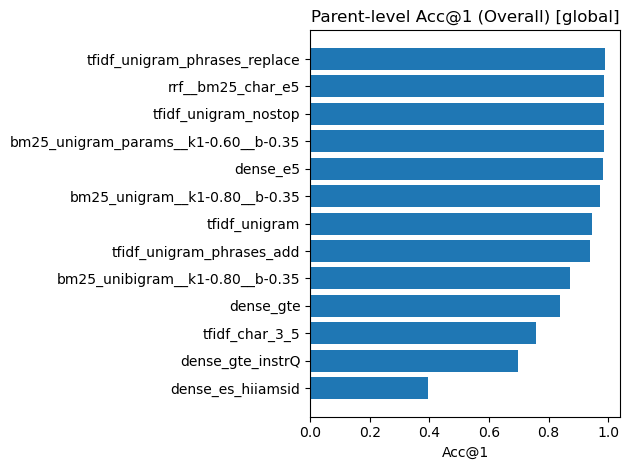

Saved plot: /work/eval/plot_parent_acc1__global.png


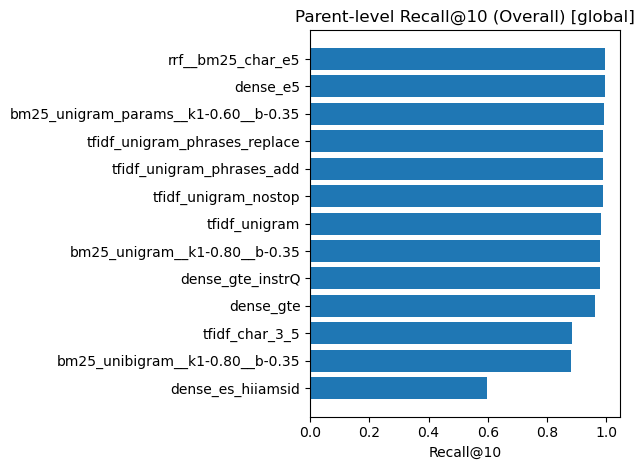

Saved plot: /work/eval/plot_parent_recall10__global.png


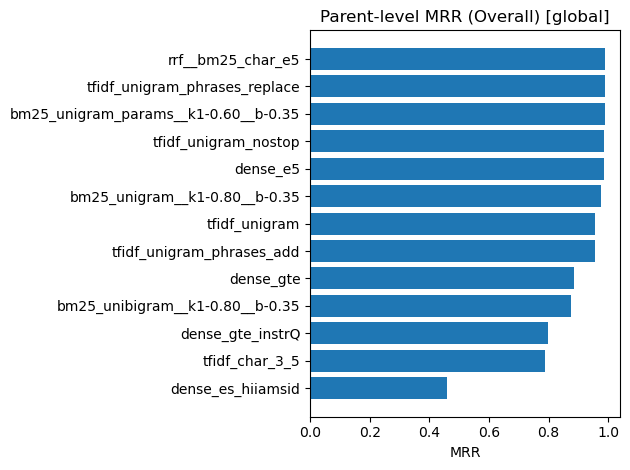

Saved plot: /work/eval/plot_parent_mrr__global.png


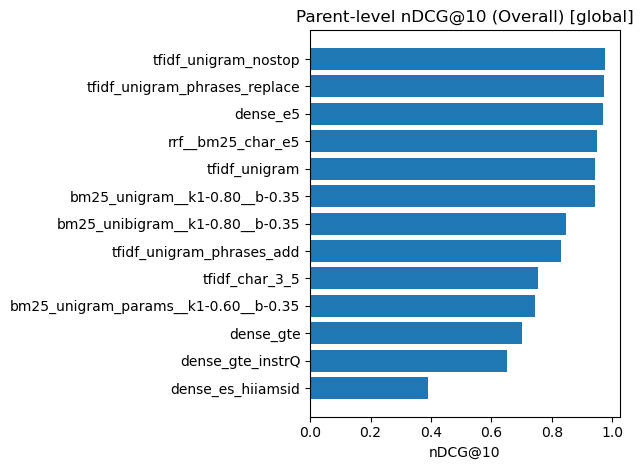

Saved plot: /work/eval/plot_parent_ndcg10__global.png


In [6]:

def barplot_metric(df: pd.DataFrame, target: str, metric: str, title: str, out_name: str):
    d = df[(df["target"]==target) & (df["scope"].str.lower()=="overall")].copy()
    d = d.sort_values(metric, ascending=False)
    plt.figure()
    plt.barh(d["method"], d[metric])
    plt.gca().invert_yaxis()
    plt.xlabel(metric)
    plt.title(title)
    plt.tight_layout()
    out_path = EVAL_OUT / out_name
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved plot:", out_path)

suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
barplot_metric(df_metrics, "item", "Acc@1",     f"Item-level Acc@1 (Overall) [{suffix}]",   f"plot_item_acc1__{suffix}.png")
barplot_metric(df_metrics, "item", "Recall@10", f"Item-level Recall@10 (Overall) [{suffix}]", f"plot_item_recall10__{suffix}.png")
barplot_metric(df_metrics, "item", "MRR",       f"Item-level MRR (Overall) [{suffix}]",     f"plot_item_mrr__{suffix}.png")
barplot_metric(df_metrics, "item", "nDCG@10",   f"Item-level nDCG@10 (Overall) [{suffix}]", f"plot_item_ndcg10__{suffix}.png")

barplot_metric(df_metrics, "parent", "Acc@1",     f"Parent-level Acc@1 (Overall) [{suffix}]",   f"plot_parent_acc1__{suffix}.png")
barplot_metric(df_metrics, "parent", "Recall@10", f"Parent-level Recall@10 (Overall) [{suffix}]", f"plot_parent_recall10__{suffix}.png")
barplot_metric(df_metrics, "parent", "MRR",       f"Parent-level MRR (Overall) [{suffix}]",     f"plot_parent_mrr__{suffix}.png")
barplot_metric(df_metrics, "parent", "nDCG@10",   f"Parent-level nDCG@10 (Overall) [{suffix}]", f"plot_parent_ndcg10__{suffix}.png")



## BM25 variant parsing & parameter plots (used in BM25_VARIANTS mode)
Method names that encode parameters (e.g., `bm25_unigram_k1_1.2_b_0.75` or `bm25_unibigram-k1-0.9-b-0.4`) are parsed to `(k1, b)`.


In [7]:

def parse_k1_b(method_name: str):
    """Extract k1 and b from method name if present.
    Examples (case-insensitive): 'bm25_unigram_k1_1.2_b_0.75', 'bm25_unibigram-k1-0.9-b-0.4'.
    Returns (k1: float|None, b: float|None).
    """
    name = method_name.lower()
    # Try k1... and b... patterns (underscore or dash separators)
    m = re.search(r'k1[\-_]?([0-9]+(?:\.[0-9]+)?)', name)
    n = re.search(r'(^|[^a-z])b[\-_]?([0-9]+(?:\.[0-9]+)?)', name)
    k1 = float(m.group(1)) if m else None
    b  = float(n.group(2)) if n else None
    return k1, b

def build_bm25_param_table(df: pd.DataFrame) -> pd.DataFrame:
    # Item-level Overall only
    d = df[(df["target"]=="item") & (df["scope"].str.lower()=="overall")].copy()
    d[["k1","b"]] = d["method"].apply(lambda s: pd.Series(parse_k1_b(s)))
    return d

if EVAL_MODE == "BM25_VARIANTS":
    param_df = build_bm25_param_table(df_metrics)
    display(param_df.head(10))

    # Table sorted by Acc@1
    best = param_df.sort_values("Acc@1", ascending=False)
    display(best[["method","k1","b","Acc@1","Recall@10","MRR","nDCG@10"]].head(20))
    best.to_csv(EVAL_OUT / f"bm25_{BM25_FAMILY}_variants_ranked.csv", index=False)

    # Scatter: Acc@1 vs k1 (marker size ~ b)
    if param_df["k1"].notna().any():
        plt.figure()
        x = param_df["k1"]
        y = param_df["Acc@1"]
        sizes = (param_df["b"].fillna(param_df["b"].median() if param_df["b"].notna().any() else 0.5) + 0.01) * 300
        plt.scatter(x, y, s=sizes)
        for _, r in param_df.iterrows():
            if pd.notna(r["k1"]) and pd.notna(r["Acc@1"]):
                plt.annotate(r["method"], (r["k1"], r["Acc@1"]))
        plt.xlabel("k1")
        plt.ylabel("Acc@1 (item)")
        plt.title(f"{BM25_FAMILY}: Acc@1 vs k1 (marker size ~ b)")
        plt.tight_layout()
        out_path = EVAL_OUT / f"bm25_{BM25_FAMILY}_acc1_vs_k1.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved plot:", out_path)

    # If both k1 & b present, grid-like scatter
    both = param_df[param_df["k1"].notna() & param_df["b"].notna()].copy()
    if not both.empty:
        plt.figure()
        plt.scatter(both["k1"], both["b"])
        for _, r in both.iterrows():
            plt.annotate(f"{r['Acc@1']:.3f}", (r["k1"], r["b"]))
        plt.xlabel("k1")
        plt.ylabel("b")
        plt.title(f"{BM25_FAMILY}: param grid (label=Acc@1)")
        plt.tight_layout()
        out_path = EVAL_OUT / f"bm25_{BM25_FAMILY}_param_grid_acc1.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved plot:", out_path)



## Optional: Latency vs accuracy (if available)
If a `latency.json` exists per run with fields like `mean_ms` or `p95_ms`, this cell will plot latency vs Acc@1.


In [8]:

def read_latency(run_dir: Path):
    p = run_dir / "latency.json"
    if p.exists():
        try:
            return json.load(open(p,"r",encoding="utf-8"))
        except Exception as e:
            print("[WARN] bad latency.json in", run_dir, e)
    return None

# Build a small table if present
lat_rows = []
for m, p in runs.items():
    lat = read_latency(p)
    if isinstance(lat, dict):
        lat_rows.append({"method": m,
                         "mean_ms": lat.get("mean_ms"),
                         "p95_ms": lat.get("p95_ms")})
df_latency = pd.DataFrame(lat_rows)
display(df_latency)

# Plot if both latency and metrics exist
if not df_latency.empty:
    # Merge with item Acc@1
    acc = df_metrics[(df_metrics["target"]=="item") & (df_metrics["scope"].str.lower()=="overall")][["method","Acc@1"]]
    d = df_latency.merge(acc, on="method", how="inner")
    if not d.empty:
        plt.figure()
        plt.scatter(d["mean_ms"], d["Acc@1"])
        for _, r in d.iterrows():
            plt.annotate(r["method"], (r["mean_ms"], r["Acc@1"]))
        plt.xlabel("Mean latency (ms)")
        plt.ylabel("Acc@1 (item)")
        plt.title("Latency vs Accuracy")
        plt.tight_layout()
        suffix = "global" if EVAL_MODE=="GLOBAL" else f"variants_{BM25_FAMILY}"
        out_path = EVAL_OUT / f"plot_latency_vs_acc1__{suffix}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved plot:", out_path)


""



## Saved artifacts
- `all_metrics_dual_merged__{global|variants_family}.(csv|json)` — merged per-run metrics.  
- `leaderboard_*_overall__{global|variants_family}.csv` — item/parent leaderboards.  
- `numeric_split_item_*__{global|variants_family}.csv` — numeric/no-numeric pivots.  
- `plot_*.png` — bar charts for paper figures.  
- **BM25_VARIANTS only**: `bm25_{family}_variants_ranked.csv`, `acc1_vs_k1`, `param_grid_acc1` plots.
